# Configurações

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from ucimlrepo import fetch_ucirepo

from c0_1_configuracoes import caminho_original, caminho_processado
from c1_0_funcoes_analise_Julia import listar_variaveis_por_tipo, analisar_variavel, plot_sex_distribution, plot_age_distribution

In [2]:
# Extensão que verifica se um dos arquivos foi alterado
%load_ext autoreload
%autoreload 2

# Dataset 1

In [3]:
def tratar_dataset1():
  # Importar base de dados
  df = pd.read_csv(f'{caminho_original}/1_Credit_Score_Classification_Dataset.csv', sep=',')

  # Renomeando colunas
  df = df.rename(columns={
      'PAY_0': 'PAY_1',
      'default.payment.next.month': 'target'
  })

  # Removendo duplicatas
  df = df.drop_duplicates()

  # Removendo colunas irrelevantes
  colunas_irrelevantes = ["ID"]
  for coluna in colunas_irrelevantes:
    df = df.drop(columns=coluna, axis=1)

  # Remoção de dados ausentes
  df = df.dropna()

  # Tratando colunas
  # SEX
  df['sensitive_sexo'] = (df['SEX'] == 1).astype(int)
  df = df.drop(columns='SEX')
  # EDUCATION
  df = df[~df['EDUCATION'].isin([0, 4, 5, 6])]
  mapeamento = {1: 2, 2: 1, 3: 0}
  df['EDUCATION'] = df['EDUCATION'].replace(mapeamento).astype(int)
  # MARRIAGE
  df = df[~df['MARRIAGE'].isin([0])]
  df['IS_MARRIAGED'] = (df['MARRIAGE'] == 1).astype(int)
  df = df.drop(columns='MARRIAGE')
  # AGE
  df = df[df['AGE'] <= 60].copy() # Removendo pessoas com mais de 60 anos
  def categorizar_idade(x):
      if x <= 30:
          return 0
      else:
          return 1
  df["sensitive_age"] = df["AGE"].apply(categorizar_idade).astype(int)
  df = df.drop(columns='AGE', axis=1)

  # Salvar
  df.to_csv(f'{caminho_processado}/Dataset1.csv', index=False)

  for col in df.columns:
      analisar_variavel(df, col)
      print(df[col].unique())

In [4]:
tratar_dataset1()

📊 Variável: LIMIT_BAL
Tipo: float64
Nulos: 0
Valores únicos: 81

Top valores:
LIMIT_BAL
50000.0     0.113219
20000.0     0.066281
30000.0     0.053990
80000.0     0.052141
200000.0    0.050190
150000.0    0.036256
100000.0    0.035195
180000.0    0.032832
360000.0    0.029477
60000.0     0.027731
Name: proportion, dtype: float64

Estatísticas descritivas:
count      29209.000000
mean      167025.700298
std       129779.190986
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64
[  20000.  120000.   90000.   50000.  500000.  100000.  140000.  200000.
  260000.  630000.   70000.  250000.  320000.  360000.  180000.  130000.
  450000.   60000.  230000.  160000.  280000.   10000.   40000.  210000.
  380000.  310000.  150000.  400000.   80000.  290000.  340000.  300000.
   30000.  240000.  470000.  350000.  330000.  110000.  420000.  170000.
  370000.  270000.  220000.  190000.  510000.  460000

# Base de dados 2

In [5]:
def tratar_dataset2():
  # Importar base de dados
  dfA = pd.read_csv(f'{caminho_original}/2_Application_Credit_Card_Approval_Prediction.csv', sep=',')
  dfB = pd.read_csv(f'{caminho_original}/2_Credit_Credit_Card_Approval_Prediction.csv', sep=',')

  # Removendo duplicatas
  dfA = dfA.drop_duplicates(subset='ID', keep="first")

  # CODE_GENDER
  dfA['sensitive_sexo'] = (dfA['CODE_GENDER'] == 'M').astype(int)
  dfA = dfA.drop(columns='CODE_GENDER', axis=1)

  # FLAG_OWN_CAR
  dfA['FLAG_OWN_CAR'] = (dfA['FLAG_OWN_CAR'] == 'Y').astype(int)

  # FLAG_OWN_REALTY
  dfA['FLAG_OWN_REALTY'] = (dfA['FLAG_OWN_REALTY'] == 'Y').astype(int)

  # CNT_CHILDREN
  bins = [-1, 0, 1, np.inf]
  labels = ['no_children', 'one_child', 'two_or_more']
  dfA['children_cat'] = pd.cut(dfA['CNT_CHILDREN'], bins=bins, labels=labels, right=True)
  dfA = dfA.drop(columns='CNT_CHILDREN', axis=1)

  # NAME_EDUCATION_TYPE
  mapeamento = {"Lower secondary": 0, "Secondary / secondary special": 1, "Incomplete higher": 2, "Higher education": 3, "Academic degree": 4,}
  dfA['ordinal_EDUCATION'] = dfA['NAME_EDUCATION_TYPE'].map(mapeamento).astype(int)
  dfA = dfA.drop('NAME_EDUCATION_TYPE', axis=1)

  # NAME_FAMILY_STATUS
  casado = ["Married", "Civil marriage"]
  dfA['IS_MARRIAGE'] = dfA['NAME_FAMILY_STATUS'].isin(casado).astype(int)
  dfA = dfA.drop('NAME_FAMILY_STATUS', axis=1)

  # DAYS_BIRTH
  dfA['ordinal_age'] = (dfA['DAYS_BIRTH'].abs() // 365).astype(int)
  dfA = dfA.drop('DAYS_BIRTH', axis=1)

  dfA = dfA[dfA['ordinal_age'] <= 60].copy() # Removendo pessoas com mais de 60 anos
  def categorizar_idade(x):
      if x <= 30:
          return 0
      else:
          return 1
  dfA["sensitive_age"] = dfA["ordinal_age"].apply(categorizar_idade).astype(int)
  dfA = dfA.drop(columns='ordinal_age', axis=1)

  # DAYS_EMPLOYED
  dfA['IS_UNEMPLOYED'] = (dfA['DAYS_EMPLOYED'] >= 0).astype(int)
  dfA = dfA.drop('DAYS_EMPLOYED', axis=1)

  # CNT_FAM_MEMBERS
  bins = [0, 1, 2, np.inf]
  labels = ['single', 'two_members', 'three_or_more']
  dfA['fam_size_cat'] = pd.cut(dfA['CNT_FAM_MEMBERS'], bins=bins, labels=labels, right=True)
  dfA = dfA.drop(columns='CNT_FAM_MEMBERS', axis=1)

  # Deletar colunas
  dfA = dfA.drop(columns={'FLAG_MOBIL', 'OCCUPATION_TYPE'}, axis=1)

  # MONTHS_BALANCE
  atraso = ['2', '3', '4', '5']
  more60 = dfB['STATUS'].astype(str).isin(atraso).astype(int)

  # TARGET
  df_target = (
      pd.DataFrame({"ID": dfB["ID"], "more60": more60})
      .groupby("ID", as_index=False)["more60"]
      .max()
      .rename(columns={"more60": "target"})
  )

  # Tratar
  df = dfA.merge(df_target, on="ID", how="inner")
  df = df.drop(columns='ID', axis=1)

  # Salvar
  df.to_csv(f'{caminho_processado}/Dataset2.csv', index=False)

  for col in df.columns:
      analisar_variavel(df, col)
      print(df[col].unique())

In [6]:
tratar_dataset2()

📊 Variável: FLAG_OWN_CAR
Tipo: int64
Nulos: 0
Valores únicos: 2

Top valores:
FLAG_OWN_CAR
0    0.604708
1    0.395292
Name: proportion, dtype: float64

Estatísticas descritivas:
count    33431.000000
mean         0.395292
std          0.488921
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: FLAG_OWN_CAR, dtype: float64
[1 0]
📊 Variável: FLAG_OWN_REALTY
Tipo: int64
Nulos: 0
Valores únicos: 2

Top valores:
FLAG_OWN_REALTY
1    0.661512
0    0.338488
Name: proportion, dtype: float64

Estatísticas descritivas:
count    33431.000000
mean         0.661512
std          0.473203
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: FLAG_OWN_REALTY, dtype: float64
[1 0]
📊 Variável: AMT_INCOME_TOTAL
Tipo: float64
Nulos: 0
Valores únicos: 243

Top valores:
AMT_INCOME_TOTAL
135000.0    0.117466
157500.0    0.086207
180000.0    0.085998
225000.0    0.082797
112500.0    

# Base de dados 3

## Base 3 - Importando a base de dados

In [7]:
def tratar_dataset3():
  # Importar base de dados
  df3 = pd.read_csv(f'{caminho_original}/3_Credit_Card_Customers.csv', sep=',')

  df = df3.copy()

  # Removendo duplicatas
  df = df.drop_duplicates()

  # Removendo colunas irrelevantes
  colunas_irrelevantes = ["CLIENTNUM", "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1", "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"]
  for coluna in colunas_irrelevantes:
    df = df.drop(columns=coluna, axis=1)

  # Remoção de dados ausentes
  df = df.dropna()

  # Tratando colunas
  # Attrition_Flag - Tornando a classe minoritária em 1
  df['target'] = (df['Attrition_Flag'] == "Attrited Customer").astype(int)
  df = df.drop(columns='Attrition_Flag', axis=1)

  # Gender
  df['sensitive_sexo'] = (df['Gender'] == 'M').astype(int)
  df = df.drop(columns='Gender', axis=1)

  # Customer_Age
  df = df[df['Customer_Age'] <= 60].copy() # Removendo pessoas com mais de 60 anos
  def categorizar_idade(x):
      if x <= 30:
          return 0
      else:
          return 1
  df["sensitive_age"] = df["Customer_Age"].apply(categorizar_idade).astype(int)
  df = df.drop(columns='Customer_Age', axis=1)

  # Salvar
  df.to_csv(f'{caminho_processado}/Dataset3.csv', index=False)

  for col in df.columns:
      analisar_variavel(df, col)
      print(df[col].unique())

In [8]:
tratar_dataset3()

📊 Variável: Dependent_count
Tipo: int64
Nulos: 0
Valores únicos: 6

Top valores:
Dependent_count
3    0.281012
2    0.270623
1    0.174141
4    0.161901
0    0.068710
5    0.043612
Name: proportion, dtype: float64

Estatísticas descritivas:
count    9722.000000
mean        2.424090
std         1.261119
min         0.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: Dependent_count, dtype: float64
[3 5 4 2 0 1]
📊 Variável: Education_Level
Tipo: object
Nulos: 0
Valores únicos: 7

Top valores:
Education_Level
Graduate         0.306624
High School      0.198005
Unknown          0.150072
Uneducated       0.147706
College          0.101214
Post-Graduate    0.051635
Doctorate        0.044744
Name: proportion, dtype: float64
['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
📊 Variável: Marital_Status
Tipo: object
Nulos: 0
Valores únicos: 4

Top valores:
Marital_Status
Married     0.463691
Single      0.385929

# Base de dados 4

In [9]:
def tratar_dataset4():
  # Configurações de paths
  out_path = Path("datasets/processed/base4.csv")

  # fetch dataset 
  statlog_german_credit_data = fetch_ucirepo(id=144) 
    
  # data (as pandas dataframes) 
  x = statlog_german_credit_data.data.features 
  y = statlog_german_credit_data.data.targets

  # Garante que a menor classe é sempre = 1
  menor_classe = y.value_counts().idxmin()
  target = (y['class'] == menor_classe).astype(int)

  # Criar a coluna 'sexo' com base nas categorias de 'Attribute 9'
  x['sensitive_sexo'] = x['Attribute9'].map({
      'A91': 1,
      'A92': 0,
      'A93': 1,
      'A94': 1,
      'A95': 0
  })

  # Definir as faixas de idade
  x = x[x['Attribute13'] <= 60].copy() # Removendo pessoas com mais de 60 anos

  # Filtrando target para manter apenas os índices que sobraram em x
  target = target.loc[x.index]

  def categorizar_idade(x):
      if x <= 30:
          return 0
      else:
          return 1
  x["sensitive_age"] = x["Attribute13"].apply(categorizar_idade).astype(int)

  # Renomear Variaveis ordinais
  variaveis_ordinais = ["Attribute8", "Attribute11", "Attribute16", "Attribute18"] 
  renomear_dict = {col: f"ordinal_{col}" for col in variaveis_ordinais}
  x = x.rename(columns=renomear_dict)

  # Excluir variaveis originais de idade e sexo para não causar redundancia
  x = x.drop(columns=['Attribute9', 'Attribute13'])

  # DATASET ORIGINAL
  # Combina x e y para criação de um unico dataset
  data = pd.concat([x, target], axis=1)
  data = data.rename(columns={target.name: "target"})
  classe_counts = data['target'].value_counts()
  print("Distribuição original da variável target:\n", classe_counts)

  # Shape final
  print("Shape:", data.shape)
  print("\nColunas:", data.columns.tolist())

  listar_variaveis_por_tipo(data)

  # Salvar
  data.to_csv(f'{caminho_processado}/Dataset4.csv', index=False)

  for col in data.columns:
      analisar_variavel(data, col)

  # Distribuição do target
  plot_sex_distribution(data, 'Base4')

Distribuição original da variável target:
 target
0    665
1    290
Name: count, dtype: int64
Shape: (955, 21)

Colunas: ['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'ordinal_Attribute8', 'Attribute10', 'ordinal_Attribute11', 'Attribute12', 'Attribute14', 'Attribute15', 'ordinal_Attribute16', 'Attribute17', 'ordinal_Attribute18', 'Attribute19', 'Attribute20', 'sensitive_sexo', 'sensitive_age', 'target']
variaveis 'object','category' = ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20']
variaveis 'int64','float64'  = ['Attribute2', 'Attribute5', 'ordinal_Attribute8', 'ordinal_Attribute11', 'ordinal_Attribute16', 'ordinal_Attribute18', 'sensitive_sexo', 'sensitive_age', 'target']
📊 Variável: Attribute1
Tipo: object
Nulos: 0
Valores únicos: 4

Top valores:
Attribute1
A14    0.394764
A11    0.274346
A12    0.269110

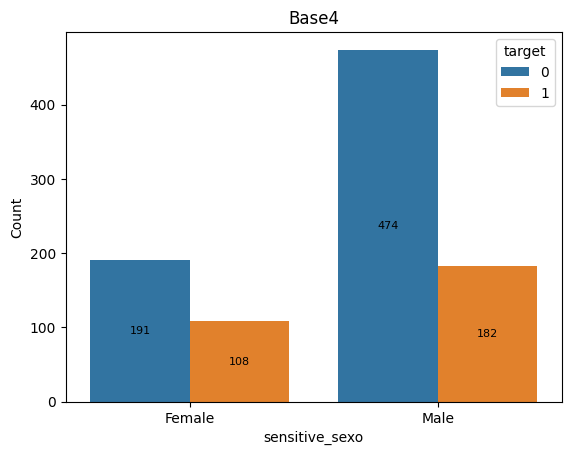

In [10]:
tratar_dataset4()